Sales Summary:
     product  total_qty   revenue
0  Headphone         16   32000.0
1     Laptop          5  300000.0
2     Mobile          8  160000.0
3     Tablet          4   60000.0


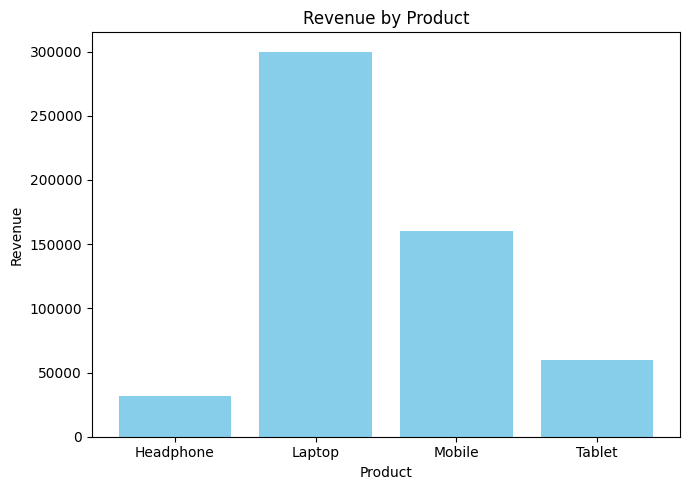

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create Database & Table

conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

cursor.execute("DROP TABLE IF EXISTS sales")

# Create table
cursor.execute("""
CREATE TABLE sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert records
sales_data = [
    (1, "Laptop", 3, 60000),
    (2, "Mobile", 5, 20000),
    (3, "Headphone", 10, 2000),
    (4, "Laptop", 2, 60000),
    (5, "Mobile", 3, 20000),
    (6, "Tablet", 4, 15000),
    (7, "Headphone", 6, 2000)
]
cursor.executemany("INSERT INTO sales VALUES (?, ?, ?, ?)", sales_data)
conn.commit()

# 2. Run SQL Query

query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""
df = pd.read_sql_query(query, conn)

# Print results
print("Sales Summary:")
print(df)


# 3. Visualization using matplotlib.pyplot

plt.figure(figsize=(7,5))
plt.bar(df['product'], df['revenue'], color='skyblue')
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.title("Revenue by Product")
plt.tight_layout()
plt.savefig("sales_chart.png")   # saves the chart
plt.show()

conn.close()


# ***Interview Questions:***
#1. How did you connect Python to a database?

Using sqlite3.connect("sales_data.db").
#2. What SQL query did you run?

SELECT product, SUM(quantity), SUM(quantity*price) FROM sales GROUP BY product.
#3. What does GROUP BY do?

It groups rows by a column (here product) so we can apply aggregate functions like SUM.
#4. How did you calculate revenue?

quantity * price inside the SQL query.
#5. How did you visualize the result?

With matplotlib.pyplot.bar().
#6. What does pandas do in your code?

It loads SQL query results into a dataframe (read_sql_query) for easy manipulation & plotting.
#7. What’s the benefit of using SQL inside Python?

SQL handles data aggregation efficiently, Python handles visualization & further analysis.
#8. Could you run the same SQL query directly in DB Browser for SQLite?

Yes, We can run the same SQL query directly in DB Browser for SQLite and get the same result.
